# <h1 style="text-align: center; font-weight: bolder;">Exercise 9: Sound and music description</h2>


With this exercise you will learn to describe sounds with simple machine learning methods. You will learn to use the Freesound API to load pre-computed sound descriptors from Freesound and to perform sound clustering and classification with them. You will work with instrumental sounds, thus learning what audio features are useful for characterizing them.

There are four parts in this exercise: 1) Download sounds and descriptors from Freesound, 2) Select two descriptors for a good sound clustering, 3) Cluster sounds using k-means, and 4) Classify sounds using k-NN.

We provide the code for each task, thus no need to get involved in much programming. 

### Relevant Concepts

#### Freesound API
With the Freesound API you can browse, search, and retrieve information from Freesound, such as automatically extracted features from audio files. You can also perform advanced queries combining content analysis features and other metadata (tags, etc...). With the API you can do text searches similar to what you can do from the advanced searches in the website http://freesound.org/search/?q, but implementing the queries in software. If you are interested in knowing more about the Freesound API, you can see examples of using it with python in: https://github.com/MTG/freesound-python/blob/master/examples.py and you can read the API documentation, http://www.freesound.org/docs/api/

#### Sound descriptors
In this exercise, you will use sound descriptors that have been pre-computed with Essentia, https://essentia.upf.edu and are stored in the Freesound database together with the corresponding sounds. Many sound descriptors can be extracted using Essentia (http://essentia.upf.edu/documentation/algorithms_reference.html) and in Freesound, a number of them are used. In the Freesound API documentation there is specifc information of the descriptors available in Freesound, https://freesound.org/docs/api/analysis_index.html.

### Euclidian distance
The Euclidian distance is the straight-line distance between two points in an n-dimensional space, thus the distance between points $p$ and $q$ is the length of the line segment connecting them. If $p = (p_1, p_2,..., p_n)$ and $q = (q_1, q_2,..., q_n)$ are two points in Euclidean n-space, then the distance, $d$, from $p$ to $q$, or from $q$ to $p$ is given by the Pythagorean formula:

$ d(p,q) = \sqrt{\sum^n_{i=1} (q_i - p_i)^2} $


### K-means clustering (k-means)
K-means clustering is a method of vector quantization that is popular for cluster analysis in data mining. K-means clustering aims to partition $n$ observations into $k$ clusters in which each observation belongs to the cluster with the nearest mean, serving as a prototype of the cluster. The problem is computationally difficult (NP-hard), however, efficient heuristic algorithms converge quickly to a local optimum. 

Given a set of observations $(x_1, x_2, …, x_n)$, where each observation is a d-dimensional real vector, k-means clustering aims to partition the $n$ observations into $k (≤ n)$ sets $S = {S_1, S_2, …, S_k}$ so as to minimize the within-cluster sum of squares (WCSS) (i.e. variance). Formally, the objective is to find:

$\underset{\mathbf{S}} {\operatorname{arg\,min}}  \sum_{i=1}^{k} \sum_{\mathbf x \in S_i} \left\| \mathbf x - \boldsymbol\mu_i \right\|^2 = \underset{\mathbf{S}} {\operatorname{arg\,min}}  \sum_{i=1}^k |S_i| \operatorname{Var} S_i$, where $μ_i$ is the mean of points in $S_i$.


### K-nearest neighbours classifier (k-NN)
K-nearest neighbours classification (k-NN) is a non-parametric method in which the input consists of the $k$ closest training examples in the feature space. The output is a class membership. An object is classified by a plurality vote of its neighbors, with the object being assigned to the class most common among its $k$ nearest neighbors ($k$ is a positive integer, typically small). If $k = 1$, then the object is simply assigned to the class of that single nearest neighbor.


# <h2 style="text-align: center; font-weight: bolder;">PART 1</h2>

## Part 1: Download sounds and descriptors from Freesound

Download a collection of instrumental sounds and their descriptors from Freesound using the Freesound API.

First get a Freesound API key from http://www.freesound.org/apiv2/apply/ and create a directory in the workspace with the name `testDownload` to store the sounds and descriptors. You also need to install the python client for the freesound API. Do this by cloning the repository https://github.com/MTG/freesound-python, into a folder and installing it following the instructions. You will have to import the freesound module in the code.

You will be calling the function `download_sounds_freesound()` whose input parameters are:
1. `queryText` (string): A single word or a string of words without spaces (use hyphens), typically the name of the instrument. e.g. (eg. "violin", "trumpet", "cello", "bassoon", etc.)
2. `tag` (string): tag to be used for filtering the searched sounds (e.g., "multisample", "single-note", "velocity", "tenuto", etc.).
3. `duration` (2 floating point numbers): min and max duration (seconds) of the sound to filter, e.g., (0.2,15).
4. `API_Key` (string): your API key.
5. `outputDir` (string): path to the directory where you want to store the sounds and their descriptors.
6. `topNResults` (integer): number of results (sounds) that you want to download.
7. `featureExt` (file extension): file extension for storing sound descriptor (.json, typically).

In the call to `download_sounds_freesound()` you will have to choose the appropriate queryText, tag, and duration, to return single notes/strokes of instrumental sounds. The first twenty results of the query should be "good". Note that the tag can be empty. Example of a query to obtain single notes of violin could be: `download_sounds_freesound(queryText='violin', API_Key=<your key>, outputDir='testDownload/', topNResults=20, duration=(0,8.5), tag='single-note')`. This returns 20 single notes of violin sounds and the script stores them in the `testDownload` directory (the directory has to be created beforehand).

Download and store twenty sound examples of each instrument using the `download_sounds_freesound()` function given below. The examples need to be representative of the instrument and coherent, single notes (melodic instruments) or single strokes (percussion instruments), and shorter than 10 seconds. Specify a good query text, tag, and duration to query for the chosen instruments. Refine your search parameters until you get twenty adequate samples for each instrument. Select three instruments to be used out of this set: violin, guitar, bassoon, trumpet, clarinet, cello, naobo (cymbals used in Beijing Opera). Listen to the sounds downloaded and look at the descriptor .json files.

Before using the API to download the sounds, we recommend to do the same query using the Freesound website and checking that the top 20 results are good.

In [1]:
import sys
print(sys.executable)

/Users/meco/MBP Files/Gits/dsp-upf/dsp-virtual-3.11/bin/python


In [30]:
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [2]:
import sys, site, pkgutil
print("Python:", sys.executable)
print("Site-packages:", site.getsitepackages())
print("Has freesound?:", any(m.name == "freesound" for m in pkgutil.iter_modules()))

Python: /Users/meco/MBP Files/Gits/dsp-upf/dsp-virtual-3.11/bin/python
Site-packages: ['/Users/meco/MBP Files/Gits/dsp-upf/dsp-virtual-3.11/lib/python3.11/site-packages']
Has freesound?: True


In [3]:
import freesound as fs
print(fs.__file__)
print(fs.__version__ if hasattr(fs, "__version__") else "no __version__")
print([m for m in dir(fs.FreesoundClient) if "search" in m.lower()])

/Users/meco/MBP Files/Gits/dsp-upf/dsp-virtual-3.11/lib/python3.11/site-packages/freesound.py
no __version__
['search']


In [4]:
import os, sys
import json
import freesound as fs

descriptors = [ 'lowlevel.spectral_centroid.mean',
                'lowlevel.spectral_contrast.mean',
                'lowlevel.dissonance.mean',
                'lowlevel.hfc.mean',
                'lowlevel.mfcc.mean',
                'sfx.logattacktime.mean',
                'sfx.inharmonicity.mean']

In [8]:
def download_sounds_freesound(queryText = "", tag=None, duration=None, API_Key = "", outputDir = "", topNResults = 5, featureExt = '.json'):
  """
  This function downloads sounds and their descriptors from freesound using the queryText and the 
  tag specified in the input. Additionally, you can also specify the duration range to filter sounds 
  based on duration.
  
  Inputs:
        (Input parameters marked with a * are optional)
        queryText (string): query text for the sounds (eg. "violin", "trumpet", "cello", "bassoon" etc.)
        tag* (string): tag to be used for filtering the searched sounds. (eg. "multisample",  
                       "single-note" etc.)
        duration* (tuple): min and the max duration (seconds) of the sound to filter, eg. (0.2,15)
        API_Key (string): your api key, which you can obtain from : www.freesound.org/apiv2/apply/
        outputDir (string): path to the directory where you want to store the sounds and their 
                            descriptors
        topNResults (integer): number of results(sounds) that you want to download 
        featureExt (string): file extension for storing sound descriptors
  output:
        This function downloads sounds and descriptors, and then stores them in outputDir. In 
        outputDir it creates a directory of the same name as that of the queryText. In this 
        directory outputDir/queryText it creates a directory for every sound with the name 
        of the directory as the sound id. Additionally, this function also dumps a text file 
        containing sound-ids and freesound links for all the downloaded sounds in the outputDir. 
        NOTE: If the directory outputDir/queryText exists, it deletes the existing contents 
        and stores only the sounds from the current query. 
  """ 
  
  # Checking for the compulsory input parameters
  if queryText == "":
    print("\n")
    print("Provide a query text to search for sounds")
    return -1
    
  if API_Key == "":
    print("\n")
    print("You need a valid freesound API key to be able to download sounds.")
    print("Please apply for one here: www.freesound.org/apiv2/apply/")
    print("\n")
    return -1
    
  if outputDir == "" or not os.path.exists(outputDir):
    print("\n")
    print("Please provide a valid output directory. This will be the root directory for storing sounds and descriptors")
    return -1    
  
  # Setting up the Freesound client and the authentication key
  fsClnt = fs.FreesoundClient()
  fsClnt.set_token(API_Key,"token")  
  
  # Creating a duration filter string that the Freesound API understands
  if duration and type(duration) == tuple:
    flt_dur = " duration:[" + str(duration[0])+ " TO " +str(duration[1]) + "]"
  else:
    flt_dur = ""
 
  if tag and type(tag) == str:
    flt_tag = "tag:"+tag
  else:
    flt_tag = ""

 
  # Querying Freesound
  page_size = 30
  if not flt_tag + flt_dur == "":
    qRes = fsClnt.search(query=queryText ,filter = flt_tag + flt_dur,sort="score", fields="id,name,previews,username,url,analysis", descriptors=','.join(descriptors), page_size=page_size, normalized=1)
  else:
    qRes = fsClnt.search(query=queryText ,sort="score",fields="id,name,previews,username,url,analysis", descriptors=','.join(descriptors), page_size=page_size, normalized=1)

  outDir2 = os.path.join(outputDir, queryText)
  if os.path.exists(outDir2):             # If the directory exists, it deletes it and starts fresh
      os.system("rm -r " + outDir2)
  os.mkdir(outDir2)

  pageNo = 1
  sndCnt = 0
  indCnt = 0
  totalSnds = min(qRes.count,200)   # System quits after trying to download after 200 times
  
  # Creating directories to store output and downloading sounds and their descriptors
  downloadedSounds = []
  while(1):
    if indCnt >= totalSnds:
      print("Not able to download required number of sounds. Either there are not enough search results on freesound for your search query and filtering constraints or something is wrong with this script.")
      break
    sound = qRes[indCnt - ((pageNo-1)*page_size)]
    print("Downloading mp3 preview and descriptors for sound with id: %s"%str(sound.id))
    outDir1 = os.path.join(outputDir, queryText, str(sound.id))
    if os.path.exists(outDir1):
      os.system("rm -r " + outDir1)
    os.system("mkdir " + outDir1)
    
    mp3Path = os.path.join(outDir1,  str(sound.previews.preview_lq_mp3.split("/")[-1]))
    ftrPath = mp3Path.replace('.mp3', featureExt)
    
    try:
      
      fs.FSRequest.retrieve(sound.previews.preview_lq_mp3, fsClnt, mp3Path)
      # Initialize a dictionary to store descriptors
      features = {}
      # Obtaining all the descriptors
      for desc in descriptors:
        features[desc]=[]
        features[desc].append(eval("sound.analysis."+desc))
      
      # Once we have all the descriptors, store them in a json file
      json.dump(features, open(ftrPath,'w'))
      sndCnt+=1
      downloadedSounds.append([str(sound.id), sound.url])

    except:
      if os.path.exists(outDir1):
        os.system("rm -r " + outDir1)
    
    indCnt +=1
    
    if indCnt%page_size==0:
      qRes = qRes.next_page()
      pageNo+=1
      
    if sndCnt>=topNResults:
      break
  # Dump the list of files and Freesound links
  fid = open(os.path.join(outDir2, queryText+'_SoundList.txt'), 'w')
  for elem in downloadedSounds:
    fid.write('\t'.join(elem)+'\n')
  fid.close()

In [9]:
# 1.1: call download_sounds_freesound for 3 instruments with parameters to obtain adequate sounds

os.makedirs("testDownload", exist_ok=True)

download_sounds_freesound(
    queryText="violin",
    tag="single-note",
    duration=(0.2, 8.5),
    API_Key="ar8bTG1XcmHJejqZZna9Z9xdMnQAjiPldWpQDqUD",
    outputDir="testDownload",
    topNResults=20,
    featureExt=".json"
)

download_sounds_freesound(
    queryText="trumpet",
    tag="single-note",
    duration=(0.2, 8.5),
    API_Key="ar8bTG1XcmHJejqZZna9Z9xdMnQAjiPldWpQDqUD",
    outputDir="testDownload",
    topNResults=20,
    featureExt=".json"
)

download_sounds_freesound(
    queryText="naobo",
    tag=None,
    duration=(0.2, 6.0),
    API_Key="ar8bTG1XcmHJejqZZna9Z9xdMnQAjiPldWpQDqUD",
    outputDir="testDownload",
    topNResults=20,
    featureExt=".json"
)




In [11]:
import os
from IPython.display import Audio, display

base_dir = "testDownload"
max_examples_per_instrument = 3

for instrument in sorted(os.listdir(base_dir)):
    instrument_path = os.path.join(base_dir, instrument)
    if not os.path.isdir(instrument_path):
        continue

    print(f"\n {instrument.upper()}:")
    count = 0

    for sound_id in os.listdir(instrument_path):
        sound_dir = os.path.join(instrument_path, sound_id)
        if not os.path.isdir(sound_dir):
            continue

        for fname in os.listdir(sound_dir):
            if fname.endswith(".mp3"):
                audio_path = os.path.join(sound_dir, fname)
                display(Audio(audio_path))
                count += 1
                break

        if count >= max_examples_per_instrument:
            break


 NAOBO:



 TRUMPET:



 VIOLIN:


# <h2 style="text-align: left; font-weight: bolder;">ANSWER FOR PART 1</h2>

### Explain the coherence of the sound collections obtained


I selected three instrumental classes: violin, trumpet, and naobo. Set up de queries to retrieve coherent collections of isolated events (like single notes for melodic instruments and single strokes for percussion) with durations shorter than 10 seconds, in order for these descriptor values to be comparable across samples.

For violin and trumpet, I used the "single-note" tag and a duration range of between 0.2 and 8.5 seconds. This filtering helps individual note recordings over phrases or long excerpts by producing a consistent set of monophonic note events. Listening to the downloaded previews confirms that the retrieved sounds are mostly single notes with clear attack and sustain portions, making them representative of their respective instruments.

For naobo (cymbals used in Beijing Opera) I did not enforce a tag (as tagging can be inconsistent for these types of sound) and limited the duration to 0.2 and 6.0 seconds to prioritize isolated cymbal strokes and avoid long recordings with multiple hits. The resulting sounds are predominantly percussive impacts with decay tails, which are representative and internally consistent for this class.

Finally, by inspecting the generated .json files, all downloaded sounds contain the expected descriptor fields: spectral centroid, dissonance, HFC, MFCCs, log-attack time, and inharmonicity. This indicates that descriptor retrieval was consistent across the collections.

# <h2 style="text-align: center; font-weight: bolder;">PART 2</h2>


## Part 2: Select two descriptors for a good sound clustering

Select two of the sound descriptors obtained from Task 1 in order to obtain a good clustering of the sounds of three instruments in a two dimensional space. By visualizing the descriptor values of the sounds in a 2D plot you can choose the features that can help to better cluster these instruments. 

You take as inputs the downloaded sounds folder (`targetDir`) and the descriptor pair indices (`descInput`) (see mapping) to create a 2-D scatter plot of the descriptor pair. The data points, sounds, from different instruments are shown with different colors. In addition, you can also plot the Freesound ID of the sounds with the points. Only plot the sounds of the 3 instruments chosen. Make sure that in `targetDir` you only have the 3 instruments chosen.

Choose a good pair of descriptors for the sounds of the 3 instruments you downloaded in Part 1. A good pair of descriptors leads to a point distribution where all the sounds of an instrument cluster together, with a good separation from the other instrument clusters. Try out different combinations of descriptor pairs. Write a short paragraph on the descriptor pairs you tried out, justifying your choices for selecting those particular descriptors. Based on the spectral and temporal features of the instruments and sounds, give an explanation of why (or why not) a good clustering is (or is not) achieved with the chosen pairs of descriptors.

From the code given you can generate a 2-D scatter plot of all sounds for the chosen descriptor pairs. 

In [16]:
for inst in dataDetails:
    print(inst, len(dataDetails[inst]))

violin 20
trumpet 20
naobo 20


In [17]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.cluster.vq import vq, kmeans, whiten

# Mapping of descriptors
descriptorMapping = { 0: 'lowlevel.spectral_centroid.mean',
                      1: 'lowlevel.dissonance.mean',
                      2: 'lowlevel.hfc.mean',
                      3: 'sfx.logattacktime.mean',
                      4: 'sfx.inharmonicity.mean',
                      5: 'lowlevel.spectral_contrast.mean.0',
                      6: 'lowlevel.spectral_contrast.mean.1',
                      7: 'lowlevel.spectral_contrast.mean.2',
                      8: 'lowlevel.spectral_contrast.mean.3',
                      9: 'lowlevel.spectral_contrast.mean.4',
                      10: 'lowlevel.spectral_contrast.mean.5',
                      11: 'lowlevel.mfcc.mean.0',
                      12: 'lowlevel.mfcc.mean.1',
                      13: 'lowlevel.mfcc.mean.2',
                      14: 'lowlevel.mfcc.mean.3',
                      15: 'lowlevel.mfcc.mean.4',
                      16: 'lowlevel.mfcc.mean.5'
                    }

In [18]:
def convFtrDict2List(ftrDict):
  """
  This function converts descriptor dictionary to an np.array. The order in the numpy array (indices) 
  are same as those mentioned in descriptorMapping dictionary.
  
  Input: 
    ftrDict (dict): dictionary containing descriptors downloaded from the freesound
  Output: 
    ftr (np.ndarray): Numpy array containing the descriptors for processing later on
  """
  ftr = []
  for key in range(len(descriptorMapping.keys())):
    try:
      ftrName, ind = '.'.join(descriptorMapping[key].split('.')[:-1]), int(descriptorMapping[key].split('.')[-1])
      ftr.append(ftrDict[ftrName][0][ind])
    except:
      ftr.append(ftrDict[descriptorMapping[key]][0])
  return np.array(ftr)

def fetchDataDetails(inputDir, descExt = '.json'):
  """
  This function is used by other functions to obtain the information regarding the directory structure 
  and the location of descriptor files for each sound 
  """
  dataDetails = {}
  for path, dname, fnames  in os.walk(inputDir):
    for fname in fnames:
      if descExt in fname.lower():
        remain, rname, cname, sname = path.split('/')[:-3], path.split('/')[-3], path.split('/')[-2], path.split('/')[-1]
        if cname not in dataDetails:
          dataDetails[cname]={}
        fDict = json.load(open(os.path.join('/'.join(remain), rname, cname, sname, fname),'r'))
        dataDetails[cname][sname]={'file': fname, 'feature':fDict}
  return dataDetails

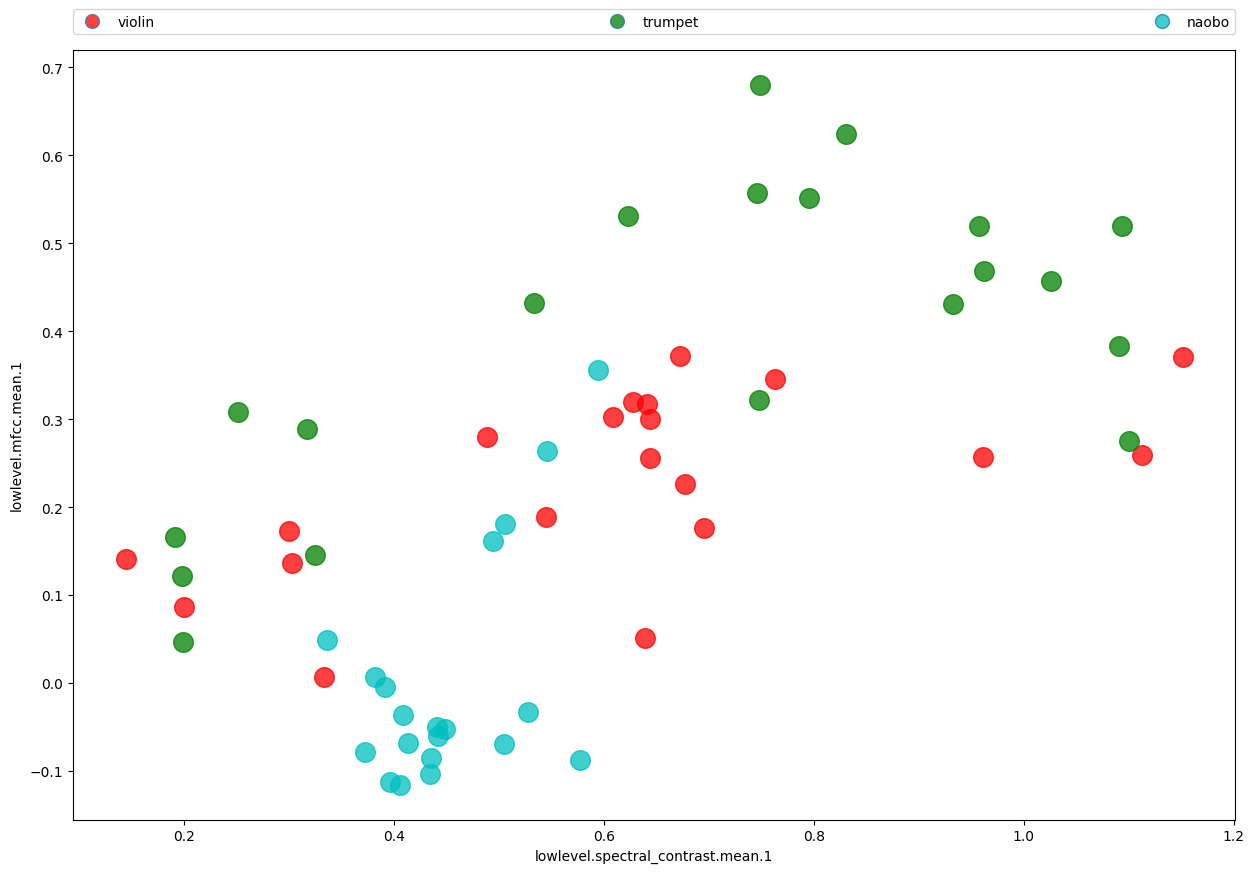

In [22]:
inputDir = "testDownload/"

### this is the main line to modify, select two descriptors, change the XX by a number from 0 to 16

descInput = (6,12)


# no need to change the code from here
anotOn = 0
dataDetails = fetchDataDetails(inputDir)
colors = ['r', 'g', 'c', 'b', 'k', 'm', 'y']

plt.figure(figsize=(15, 10))

legArray = []
catArray = []
for ii, category in enumerate(dataDetails.keys()):
    catArray.append(category)
    for soundId in dataDetails[category].keys():
        filepath = os.path.join(inputDir, category, soundId, dataDetails[category][soundId]['file'])
        descSound = convFtrDict2List(json.load(open(filepath, 'r')))
        x_cord = descSound[descInput[0]]
        y_cord = descSound[descInput[1]]
        plt.scatter(x_cord, y_cord, c = colors[ii], s=200, alpha=0.75)
        if anotOn==1:
            plt.annotate(soundId, xy=(x_cord, y_cord), xytext=(x_cord, y_cord))
    circ = Line2D([0], [0], linestyle="none", marker="o", alpha=0.75, markersize=10, markerfacecolor=colors[ii])
    legArray.append(circ)
  
plt.ylabel(descriptorMapping[descInput[1]])
plt.xlabel(descriptorMapping[descInput[0]])
plt.legend(legArray,catArray,numpoints=1,bbox_to_anchor=(0.,1.02,1.,.102),loc=3,ncol=len(catArray),mode="expand",borderaxespad=0.)

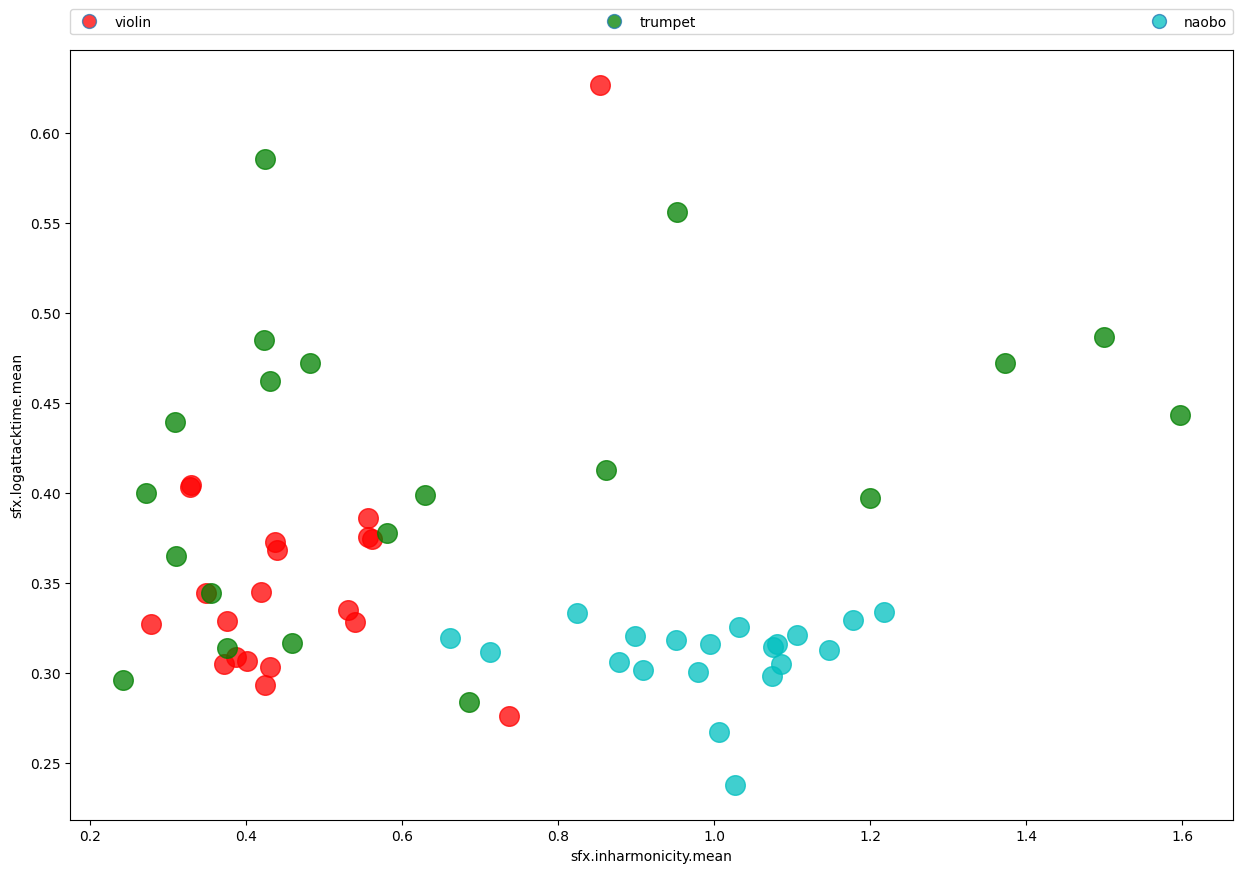

In [24]:
inputDir = "testDownload/"

### this is the main line to modify, select two descriptors, change the XX by a number from 0 to 16

descInput = (4,3)


# no need to change the code from here
anotOn = 0
dataDetails = fetchDataDetails(inputDir)
colors = ['r', 'g', 'c', 'b', 'k', 'm', 'y']

plt.figure(figsize=(15, 10))

legArray = []
catArray = []
for ii, category in enumerate(dataDetails.keys()):
    catArray.append(category)
    for soundId in dataDetails[category].keys():
        filepath = os.path.join(inputDir, category, soundId, dataDetails[category][soundId]['file'])
        descSound = convFtrDict2List(json.load(open(filepath, 'r')))
        x_cord = descSound[descInput[0]]
        y_cord = descSound[descInput[1]]
        plt.scatter(x_cord, y_cord, c = colors[ii], s=200, alpha=0.75)
        if anotOn==1:
            plt.annotate(soundId, xy=(x_cord, y_cord), xytext=(x_cord, y_cord))
    circ = Line2D([0], [0], linestyle="none", marker="o", alpha=0.75, markersize=10, markerfacecolor=colors[ii])
    legArray.append(circ)
  
plt.ylabel(descriptorMapping[descInput[1]])
plt.xlabel(descriptorMapping[descInput[0]])
plt.legend(legArray,catArray,numpoints=1,bbox_to_anchor=(0.,1.02,1.,.102),loc=3,ncol=len(catArray),mode="expand",borderaxespad=0.)

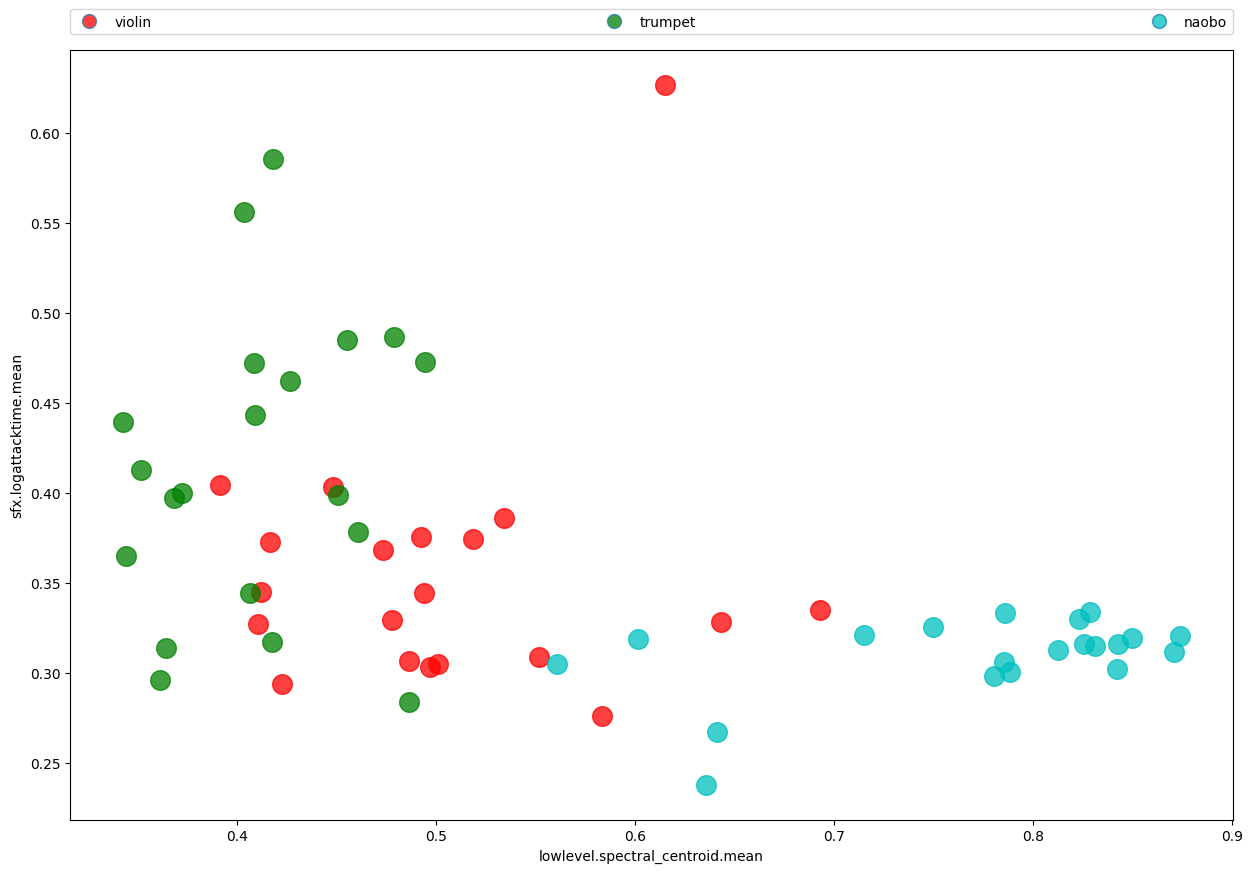

In [25]:
inputDir = "testDownload/"

### this is the main line to modify, select two descriptors, change the XX by a number from 0 to 16

descInput = (0,3)


# no need to change the code from here
anotOn = 0
dataDetails = fetchDataDetails(inputDir)
colors = ['r', 'g', 'c', 'b', 'k', 'm', 'y']

plt.figure(figsize=(15, 10))

legArray = []
catArray = []
for ii, category in enumerate(dataDetails.keys()):
    catArray.append(category)
    for soundId in dataDetails[category].keys():
        filepath = os.path.join(inputDir, category, soundId, dataDetails[category][soundId]['file'])
        descSound = convFtrDict2List(json.load(open(filepath, 'r')))
        x_cord = descSound[descInput[0]]
        y_cord = descSound[descInput[1]]
        plt.scatter(x_cord, y_cord, c = colors[ii], s=200, alpha=0.75)
        if anotOn==1:
            plt.annotate(soundId, xy=(x_cord, y_cord), xytext=(x_cord, y_cord))
    circ = Line2D([0], [0], linestyle="none", marker="o", alpha=0.75, markersize=10, markerfacecolor=colors[ii])
    legArray.append(circ)
  
plt.ylabel(descriptorMapping[descInput[1]])
plt.xlabel(descriptorMapping[descInput[0]])
plt.legend(legArray,catArray,numpoints=1,bbox_to_anchor=(0.,1.02,1.,.102),loc=3,ncol=len(catArray),mode="expand",borderaxespad=0.)

'\n\n\n'

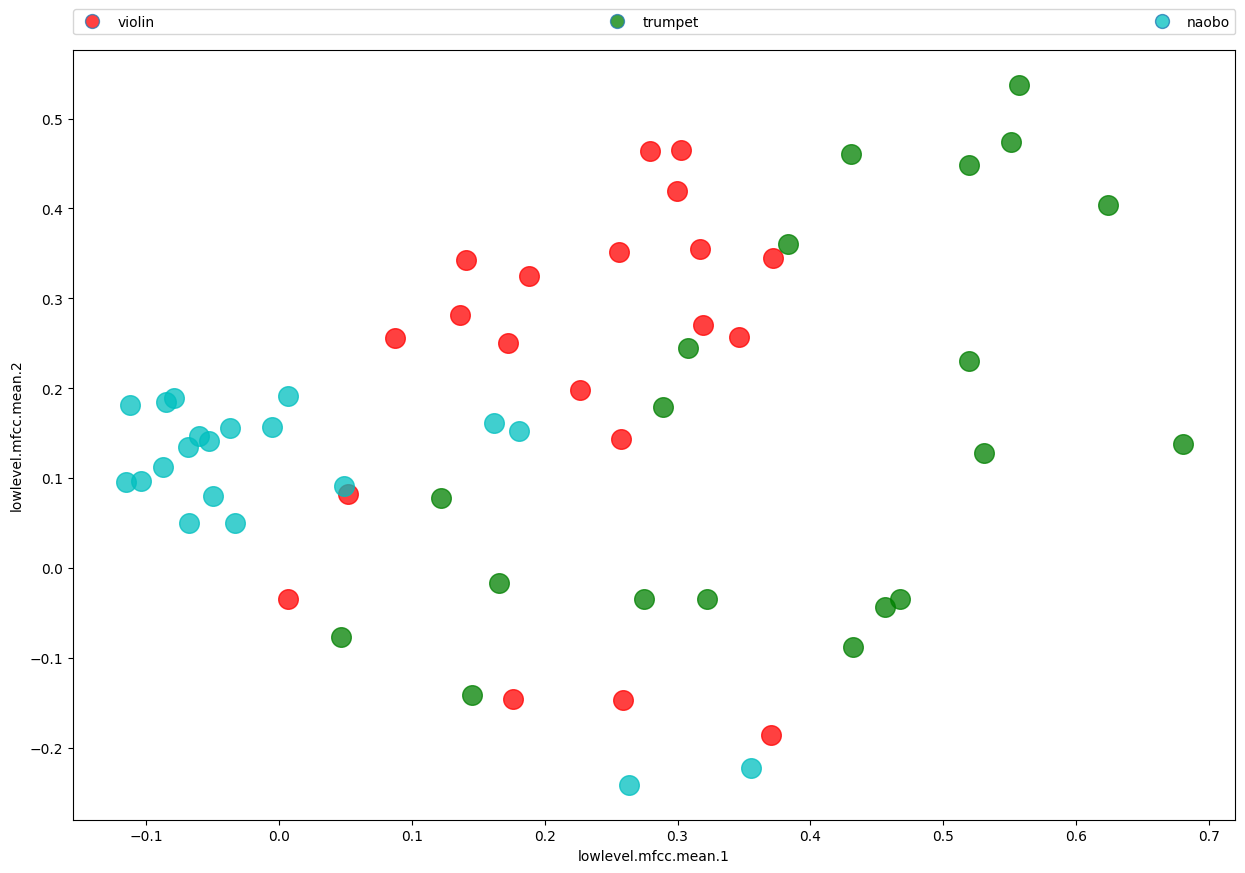

In [26]:
# 2.2: Select the descriptors to plot of the three instruments chosen
inputDir = "testDownload/"

### this is the main line to modify, select two descriptors, change the XX by a number from 0 to 16

descInput = (12,13)


# no need to change the code from here
anotOn = 0
dataDetails = fetchDataDetails(inputDir)
colors = ['r', 'g', 'c', 'b', 'k', 'm', 'y']

plt.figure(figsize=(15, 10))

legArray = []
catArray = []
for ii, category in enumerate(dataDetails.keys()):
    catArray.append(category)
    for soundId in dataDetails[category].keys():
        filepath = os.path.join(inputDir, category, soundId, dataDetails[category][soundId]['file'])
        descSound = convFtrDict2List(json.load(open(filepath, 'r')))
        x_cord = descSound[descInput[0]]
        y_cord = descSound[descInput[1]]
        plt.scatter(x_cord, y_cord, c = colors[ii], s=200, alpha=0.75)
        if anotOn==1:
            plt.annotate(soundId, xy=(x_cord, y_cord), xytext=(x_cord, y_cord))
    circ = Line2D([0], [0], linestyle="none", marker="o", alpha=0.75, markersize=10, markerfacecolor=colors[ii])
    legArray.append(circ)
  
plt.ylabel(descriptorMapping[descInput[1]])
plt.xlabel(descriptorMapping[descInput[0]])
plt.legend(legArray,catArray,numpoints=1,bbox_to_anchor=(0.,1.02,1.,.102),loc=3,ncol=len(catArray),mode="expand",borderaxespad=0.)

#### Explain the results
"""


"""

# <h2 style="text-align: left; font-weight: bolder;">ANSWER FOR PART 2</h2>

### Explain the results


To evaluate the most suitable descriptors for clustering , several pairs of descriptors were tested and visualized in a two dimensional space.

* (0,3): Spectral centroid vs log attack time:
    * This combination separates mainly percusive sounds from sustained sounds.
    * Naobo sampled usually appear with:
        * High spectral centroid values
        * Shorter log attack times
    * Violin and trumpet samples overlap significantly. This indicates:
        * These descriptors capture brightness and temporal onset perhaps.
        * THey are insufficient as well to make a distinction between melodic instruments with similar note behavior.
    * Clustering looks good here

* (2,3): HFC vs Log attack time
    * This pair improves separation of naobo from melodic sounds.
    * High frequency content emphasizes the noise and impulsive nature of the cymbal strokes.
    * Violin and trumpet overlap anyhow.
    * Conclusion:
        * Effective for identifying percussive vs sustained sounds.
        * Weak for distinguishing instruments with similar harmonic structure.

* (0,3) & (6,12): Spectral centroid & Log attack time vs Spectral contrast and MFCC
    * These 2 plots have similarities:
        * 0,3 highlights temporal and energetic differences
        * 6,12 highlights spectral shape and timbre
    * Spectral contrast along with MFCC providess better separation for:
        * Violin and trumpet compared to temporal descriptors.
    * SOme overlap exists anyhow in both.

* (6,12): Spectral contrast vs MFCC coefficient 1
    * This starts to show a clearer grouping for the 3 instruments.
    * Naobo samples cluster in a more compact way. Mainly cause high spectral contrast caused by noise.
    * This shows that spectral contrast captures differences in harmonic and noisy distributions.

* (12,13): MFCC coeff 1 vs MFCC coeff 2
    * This one provides a good visual separation 
    * Naobo forms a tight cluster
    * Vilin and trumpet occupy different regions of the feature space and barely overlap.
    * FCC effectively encode:
        * Glogal spectral envelope
        * Perceptual timbral characteristics.
    * This shows MFCC is more suitable for distinguishing melodic instruments.




# <h2 style="text-align: center; font-weight: bolder;">PART 3</h2>


## Part 3: Cluster sounds using k-means

After visualizing the sound descriptors, you will now cluster the sounds using more than two descriptors. You can use as many descriptors as you need for the best clustering. Use the same set of sounds obtain in Task 1, starting from the descriptors that you found were good in Part 2, and then adding other descriptors that you feel can improve the kmeans clustering of sounds. The function `cluster_sounds()` takes the sounds folder (targetDir), number of clusters (nCluster) and the descriptor indices (descInput) as input. It then performs a kmeans clustering using the selected descriptors. Make sure that in targetDir you only have the 3 instruments chosen.

For this part, you can use as many descriptors as you need to achieve good clustering and classification performance. However it is best to use as few descriptors as possible in order to make it easier to explain the contribution of each descriptor. Choose the number of clusters to be the same as the number of instruments (i.e., 3). Ideally in such a case, all the sounds of an instrument should go into a single cluster. In reality however, there might be sounds that are outliers and can go into a different cluster. The algorithm takes a majority vote on the sounds in each of the three clusters and assigns each cluster to an instrument. We compute the performance of the clustering by checking the number of points (sounds), that have been wrongly assigned to a cluster. The function clusterSounds() prints the clusters and the sounds assigned to each one. The function also prints the resulting classification obtained with the choice of descriptors you made.

Write a short paragraph explaining the descriptors you used, the resulting classification accuracy you obtained, and your observations on why you obtained (or not) those errors in clustering. Comment if you see any systematic errors (such as a consistent mix up of sounds from two instruments) and possible reasons for that. You should also try to cluster with different subsets of descriptors and mention the classification accuracy you obtain in each case.

Note: Since the cluster centers are randomly initialized every time in k-means, you might see different results every time you run the function. You can report the best result you obtained.

In [28]:
def cluster_sounds(targetDir, nCluster = -1, descInput=[]):
  """
  This function clusters all the sounds in targetDir using kmeans clustering.
  
  Input:
    targetDir (string): Directory where sound descriptors are stored (all the sounds in this 
                        directory will be used for clustering)
    nCluster (int): Number of clusters to be used for kmeans clustering.
    descInput (list) : List of indices of the descriptors to be used for similarity/distance 
                       computation (see descriptorMapping)
  Output:
    Prints the class of each cluster (computed by a majority vote), number of sounds in each 
    cluster and information (sound-id, sound-class and classification decision) of the sounds 
    in each cluster. Optionally, you can uncomment the return statement to return the same data.
  """
  
  dataDetails = fetchDataDetails(targetDir)
  
  ftrArr = []
  infoArr = []
  
  if nCluster ==-1:
    nCluster = len(dataDetails.keys())
  for cname in dataDetails.keys():
    #iterating over sounds
    for sname in dataDetails[cname].keys():
      ftrArr.append(convFtrDict2List(dataDetails[cname][sname]['feature'])[descInput])
      infoArr.append([sname, cname])
  
  ftrArr = np.array(ftrArr)
  infoArr = np.array(infoArr)
  
  ftrArrWhite = whiten(ftrArr)
  centroids, distortion = kmeans(ftrArrWhite, nCluster)
  clusResults = -1*np.ones(ftrArrWhite.shape[0])
  
  for ii in range(ftrArrWhite.shape[0]):
    diff = centroids - ftrArrWhite[ii,:]
    diff = np.sum(np.power(diff,2), axis = 1)
    indMin = np.argmin(diff)
    clusResults[ii] = indMin
  
  ClusterOut = []
  classCluster = []
  globalDecisions = []  
  for ii in range(nCluster):
    ind = np.where(clusResults==ii)[0]
    freqCnt = []
    for elem in infoArr[ind,1]:
      freqCnt.append(infoArr[ind,1].tolist().count(elem))
    indMax = np.argmax(freqCnt)
    classCluster.append(infoArr[ind,1][indMax])
    
    print("\n(Cluster: " + str(ii) + ") Using majority voting as a criterion this cluster belongs to " + 
          "class: " + classCluster[-1])
    print ("Number of sounds in this cluster are: " + str(len(ind)))
    decisions = []
    for jj in ind:
        if infoArr[jj,1] == classCluster[-1]:
            decisions.append(1)
        else:
            decisions.append(0)
    globalDecisions.extend(decisions)
    print ("sound-id, sound-class, classification decision")
    ClusterOut.append(np.hstack((infoArr[ind],np.array([decisions]).T)))
    print (ClusterOut[-1])
  globalDecisions = np.array(globalDecisions)
  totalSounds = len(globalDecisions)
  nIncorrectClassified = len(np.where(globalDecisions==0)[0])
  print("Out of %d sounds, %d sounds are incorrectly classified considering that one cluster should "
        "ideally contain sounds from only a single class"%(totalSounds, nIncorrectClassified))
  print("You obtain a classification (based on obtained clusters and majority voting) accuracy "
         "of %.2f percentage"%round(float(100.0*float(totalSounds-nIncorrectClassified)/totalSounds),2))
  # return ClusterOut

In [37]:
# 3.1: Run the function clusterSounds 
### your code here


inputDir = "testDownload/"
nCluster = 3


print(color.BOLD + "Set A: [12, 13, 4] (MFCC1, MFCC2, Inharmonicity)" + color.END)
cluster_sounds(inputDir, nCluster=nCluster, descInput=[12, 13, 4])

print(color.BOLD + "\nSet B: [12, 13, 14] (MFCC1, MFCC2, MFCC3)" + color.END)
cluster_sounds(inputDir, nCluster=nCluster, descInput=[12, 13, 14])

print(color.BOLD + "\nSet C: [12, 13, 3] (MFCC1, MFCC2, LogAttackTime)" + color.END)
cluster_sounds(inputDir, nCluster=nCluster, descInput=[12, 13, 3])

Set A: [12, 13, 4] (MFCC1, MFCC2, Inharmonicity)

(Cluster: 0) Using majority voting as a criterion this cluster belongs to class: trumpet
Number of sounds in this cluster are: 14
sound-id, sound-class, classification decision
[['374611' 'violin' '0']
 ['374617' 'violin' '0']
 ['374614' 'violin' '0']
 ['374613' 'violin' '0']
 ['374181' 'trumpet' '1']
 ['374180' 'trumpet' '1']
 ['374174' 'trumpet' '1']
 ['374176' 'trumpet' '1']
 ['374182' 'trumpet' '1']
 ['374178' 'trumpet' '1']
 ['374179' 'trumpet' '1']
 ['374177' 'trumpet' '1']
 ['222282' 'naobo' '0']
 ['222281' 'naobo' '0']]

(Cluster: 1) Using majority voting as a criterion this cluster belongs to class: violin
Number of sounds in this cluster are: 23
sound-id, sound-class, classification decision
[['374568' 'violin' '1']
 ['374566' 'violin' '1']
 ['374567' 'violin' '1']
 ['374569' 'violin' '1']
 ['374574' 'violin' '1']
 ['374573' 'violin' '1']
 ['374575' 'violin' '1']
 ['374562' 'violin' '1']
 ['374565' 'violin' '1']
 ['374564' 'vi

**Question E9 - 3.2:**

# <h2 style="text-align: left; font-weight: bolder;">ANSWER 3.2</h2>

### Explain the results


**_Experimental setup_**
* Dataset mainly of 60 sounds:
    * 20 violin
    * 20 trumpet
    * 20 naobo
* CLustering method: k means with k=3, one cluster per instrument
* Cluster labels were assigned using majority voting
* Feature subsets were selected based on the 2D descriptor analysis in part 2

**Set A: [12, 13, 4] (MFCC1, MFCC2, Inharmonicity)**
* Accuracy of 66.6% (basically 20 incorrectly classified sounds)
* Observed behavior:
    * Naobo forms a compact cluster, perhaps driven by high inharmonicity
    * Violin forms a decent cluster
    * Trumpet forms the smalles cluster
* Errors:
    * Strong confussion between violin and trumpet. Several sounds assigned to the violin cluster and viceversa.
    * A few violin and trumpet sounds leak into the naobo cluster.
* Interpretation:
    * Inharmonicity is very effective at separating percurssive and harmonic sounds. Although it's less useful for distinguishing between two harmonic instruments (like violin and trumpet).
    * MFCC1 and MFCC2 alone do not fully capture articulation and timbral differences between sustained melodic instruments.


**Set B: [12, 13, 14] (MFCC1, MFCC2, MFCC3)**
* Accuracy of 68.3% (basically 19 incorrectly classified sounds)
* Observed behavior:
    * Naobo cluster is stable
    * Violin forms the largest cluster: 26 sounds
    * Trumpet cluster remains small
* Errors:
    * Persistent confussion of violin and trumpet. Trumpet gets mixed with violin
* Interpretation:
    * Adding MFCC3 improves spectral detail and slightly improves overall accuracy


**Set C: [12, 13, 3] (MFCC1, MFCC2, LogAttackTime)**
* Accuracy of 63.3% (basically 22 incorrectly classified sounds)
* Observed behavior:
    * Naobo remains well grouped 
    * Violin and trumpet clusters overlap
* Errors:
    * Several violin and trumpet sounds mixed with the naobo cluster
* Interpretation:
    * LogAttackTime seems sensitive to recording conditions, playing technique or trimming.
    * Attack features introduced variability, insted of improving the discrimination.



**OVERALL CONCLUSIONS**

* The best performing set was B with the highest accuracy.
* Naobo is consistently easier to identify and cluster. Most likely due to its inhamornic nature and noise like spectral structure.
* The predominant source of error is violin vs trumpet confussion, cause by their similar harmonic structure.
* Using a small number of carefully selected descriptors provides a reasonable clustering performance.

____

# <h2 style="text-align: center; font-weight: bolder;">PART 4</h2>

## Part 4: Classify sounds with k-NN

Assign a sound different from the sounds of the 3 instruments chosen to one of the 3 instrumental classes you chose in Part 1, using the k-nearest neighbours classifier (k-NN). 

Given a new sound (query sound) and its descriptors, use the function `classify_sound_kNN()` for doing a k-NN classification. It uses a distance measure based on Euclidian distance which is implemented in `compute_similar_sounds()`. `classify_sound_kNN()` returns the instrument class that the query sound is classified into. 

The goal of the exercise is to experiment with the k-NN classifier and be able to understand the result by being able to explain why a particular query sound, that is not from any of the defined classes, is actually classified to one of those classes.

4.1 Get query sounds from Freesound. To get query sounds and their descriptors, you can use `download_sounds_freesound()` function using different query texts (as you did in Part 1). Get sounds that are not from the 3 instruments you chose in Part 1, or at least that is none of the sounds you used to define the classes. If you use a sound from one of the three instruments make sure that is different enough from the existing sounds in your collections.

4.2 Perform 5 classifications. You can use as many descriptors as you need (the fewer you use, the easier it will be, to explain the result). k is usually chosen to be an odd positive integer. Try out with different query sounds, different subsets of descriptors, and different values of k. Explain the reason for choosing the descriptors you used and the value of k you selected. Include cases where you think the classification is incorrect, and cases with a query sound of an instrument different from the starting classes. By trying out a sound from a different instrument, you are classifying the sound into the closest instrument class, which can tell you about similarity between instruments.

In [38]:
def compute_similar_sounds(queryFile, targetDir, descInput = []):
  """
  This function returns similar sounds for a specific queryFile. Given a queryFile this function 
  computes the distance of the query to all the sounds found in the targetDir and sorts them in 
  the increasing order of the distance. This way we can obtain similar sounds to a query sound.
  
  Input:
    queryFile (string): Descriptor file (.json, unless changed)
    targetDir (string): Target directory to search for similar sounds (using their descriptor files)
    descInput (list) : list of indices of the descriptors to be used for similarity/distance computation 
                       (see descriptorMapping)
  Output: 
    List containing an ordered list of similar sounds. 
  """
  
  dataDetails = fetchDataDetails(targetDir)
  
  #reading query feature dictionary
  qFtr = json.load(open(queryFile, 'r'))
  dist = []
  # Iterating over classes
  for cname in dataDetails.keys():
    # Iterating over sounds
    for sname in dataDetails[cname].keys():
      f1 =  convFtrDict2List(qFtr)
      f2 =  convFtrDict2List(dataDetails[cname][sname]['feature'])
      eucDist = np.sqrt(np.sum(np.power(np.array(f1[descInput]) - np.array(f2[descInput]), 2)))
      dist.append([eucDist, sname, cname])
  
  # Sorting the array based on the distance
  indSort = np.argsort(np.array(dist)[:,0])
  return (np.array(dist)[indSort,:]).tolist()

        
def classify_sound_kNN(queryFile, targetDir, K, descInput = []):
  """
  This function performs the KNN classification of a sound. The nearest neighbors are chosen from 
  the sounds in the targetDir.
   
  Input:
    queryFile (string): Descriptor file (.json, unless changed)
    targetDir (string): Target directory to search for similar sounds (using their descriptor files)
    K (int) : Number of nearest neighbors to consider for KNN classification.
    descInput (list) : List of indices of the descriptors to be used for similarity/distance computation 
                      (see descriptorMapping)
  Output:
    predClass (string): Predicted class of the query sound
  """
  distances = compute_similar_sounds(queryFile, targetDir, descInput)
  if len(np.where((np.array(distances)[:,0].astype(np.float64))==0)[0])>0:
    print("Warning: We found an exact copy of the query file in the target directory. "
          "Beware of duplicates while doing KNN classification.")
  
  classes = (np.array(distances)[:K,2]).tolist()
  freqCnt = []
  for ii in range(K):
    freqCnt.append(classes.count(classes[ii]))
  indMax = np.argmax(freqCnt)
  predClass =  classes[indMax]
  print ("This sample belongs to class: " + str(predClass))
  return predClass


In [42]:
def get_first_descriptor(queryDir):
    sound_ids = [
        d for d in os.listdir(queryDir)
        if os.path.isdir(os.path.join(queryDir, d))
    ]
    sound_id = sound_ids[0]
    json_file = [
        f for f in os.listdir(os.path.join(queryDir, sound_id))
        if f.endswith(".json")
    ][0]
    return os.path.join(queryDir, sound_id, json_file)

In [43]:
# 4.1 download one sound 
### your code here

# download query sounds (havent used them in training)

os.makedirs("querySounds", exist_ok=True)

download_sounds_freesound(
    queryText="cello",
    tag="single-note",
    duration=(0.3, 8.0),
    API_Key="ar8bTG1XcmHJejqZZna9Z9xdMnQAjiPldWpQDqUD",
    outputDir="querySounds",
    topNResults=1,
    featureExt=".json"
)

download_sounds_freesound(
    queryText="trombone",
    tag="single-note",
    duration=(0.3, 8.0),
    API_Key="ar8bTG1XcmHJejqZZna9Z9xdMnQAjiPldWpQDqUD",
    outputDir="querySounds",
    topNResults=1,
    featureExt=".json"
)

download_sounds_freesound(
    queryText="gong",
    tag=None,
    duration=(0.3, 8.0),
    API_Key="ar8bTG1XcmHJejqZZna9Z9xdMnQAjiPldWpQDqUD",
    outputDir="querySounds",
    topNResults=1,
    featureExt=".json"
)

**Question E9 - 4.2:**


# <h2 style="text-align: left; font-weight: bolder;">ANSWER 4.2</h2>

### Explain your choices


**CHOICE OF SOUNDS**

* Cello was chosen as a bowed string instrument similar to violin in mechanics.
* Trombone was chosen as a brass instrument, similar to trumpet.
* Gong was chosen as a percussive inharmonic sound, similar to naobo.

**DESCRIPTORS**

* The descriptor set 12, 13, 14 (MFCC1, MFCC2, MFCC3) was chosen because:
    * MFCCs encode global spectral envelope and it can be related to perceived timbre.
    * In part 2 and 3 the MFCC descriptors showed the best discrimination among instruments.
    * They provide a compact representation, so it's easier to interpret with kNN

* Choise of K=5:
    * It's an odd number so it avoids ties in the voting
    * It provides balance between sensitivity and robustness
    * It reduces the impact of the outliners compared to very small k values


___


In [53]:
# 4.3 classify the donwloaded sound
### your code here

targetDir = "testDownload/"
descInput = [12, 13, 14]
K = 5

print(color.BOLD + "Cello:" + color.END)
classify_sound_kNN(
    queryFile=get_first_descriptor("querySounds/cello"),
    targetDir=targetDir,
    K=K,
    descInput=descInput
)

print(color.BOLD + "\nTrombone:" + color.END)
classify_sound_kNN(
    queryFile=get_first_descriptor("querySounds/trombone"),
    targetDir=targetDir,
    K=K,
    descInput=descInput
)

print(color.BOLD + "\nGong:" + color.END)
classify_sound_kNN(
    queryFile=get_first_descriptor("querySounds/gong"),
    targetDir=targetDir,
    K=K,
    descInput=descInput
)


Cello:
This sample belongs to class: violin

Trombone:
This sample belongs to class: trumpet

Gong:
This sample belongs to class: trumpet


'trumpet'

**Question E9 - 4.4:**

# <h2 style="text-align: left; font-weight: bolder;">ANSWER 4.4</h2>

### Explain the classification

The results obtained using kNN with MFCC descriptors = 5 were:


___

___
# <h2 style="text-align: center; font-weight: bolder;">ALTERNATIVE TESTS </h2>


In [54]:
# TEST A: alternative descriptor sets (same k-NN)

targetDir = "testDownload/"
K = 5

descriptor_sets = {
    "A1: Percussive vs harmonic (centroid, HFC, attack, inharm, contrast1)": [0, 2, 3, 4, 6],
    "A2: Add timbre ( + MFCC1, MFCC2)": [0, 2, 3, 4, 6, 12, 13],
    "A3: Mostly MFCC (MFCC1-3) baseline": [12, 13, 14],
    "A4: Attack + inharm + MFCC1-2": [3, 4, 12, 13],
}

queries = {
    "Cello": get_first_descriptor("querySounds/cello"),
    "Trombone": get_first_descriptor("querySounds/trombone"),
    "Gong": get_first_descriptor("querySounds/gong"),
}

for set_name, descInput in descriptor_sets.items():
    print(color.BOLD + f"\n--- {set_name} | descInput={descInput} ---" + color.END)
    for qname, qfile in queries.items():
        print(color.BOLD + f"\n{qname}:" + color.END)
        classify_sound_kNN(
            queryFile=qfile,
            targetDir=targetDir,
            K=K,
            descInput=descInput
        )


--- A1: Percussive vs harmonic (centroid, HFC, attack, inharm, contrast1) | descInput=[0, 2, 3, 4, 6] ---

Cello:
This sample belongs to class: naobo

Trombone:
This sample belongs to class: violin

Gong:
This sample belongs to class: violin

--- A2: Add timbre ( + MFCC1, MFCC2) | descInput=[0, 2, 3, 4, 6, 12, 13] ---

Cello:
This sample belongs to class: naobo

Trombone:
This sample belongs to class: trumpet

Gong:
This sample belongs to class: violin

--- A3: Mostly MFCC (MFCC1-3) baseline | descInput=[12, 13, 14] ---

Cello:
This sample belongs to class: violin

Trombone:
This sample belongs to class: trumpet

Gong:
This sample belongs to class: trumpet

--- A4: Attack + inharm + MFCC1-2 | descInput=[3, 4, 12, 13] ---

Cello:
This sample belongs to class: trumpet

Trombone:
This sample belongs to class: trumpet

Gong:
This sample belongs to class: trumpet


In [ ]:
# TEST B: kNN with normalization + distance weighted voting 

import numpy as np
import json
import os

def build_dataset_matrix(targetDir, descInput):
    dataDetails = fetchDataDetails(targetDir)
    X, y, ids = [], [], []
    for cname in dataDetails:
        for sid in dataDetails[cname]:
            f = convFtrDict2List(dataDetails[cname][sid]['feature'])[descInput]
            X.append(f)
            y.append(cname)
            ids.append(sid)
    return np.array(X, dtype=float), np.array(y), np.array(ids)

def zscore_fit(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    return mu, sigma

def zscore_transform(X, mu, sigma):
    return (X - mu) / sigma

def knn_weighted_predict(queryFile, targetDir, K, descInput, eps=1e-9, verbose=True):
    # build training matrix
    X, y, ids = build_dataset_matrix(targetDir, descInput)
    mu, sigma = zscore_fit(X)
    Xn = zscore_transform(X, mu, sigma)

    # query vector
    qFtr = json.load(open(queryFile, "r"))
    q = convFtrDict2List(qFtr)[descInput].astype(float)
    qn = zscore_transform(q, mu, sigma)

    # distances
    d = np.sqrt(((Xn - qn) ** 2).sum(axis=1))
    nn_idx = np.argsort(d)[:K]

    # distanceweighted vote
    weights = 1.0 / (d[nn_idx] + eps)
    class_scores = {}
    for w, cls in zip(weights, y[nn_idx]):
        class_scores[cls] = class_scores.get(cls, 0.0) + float(w)

    pred = max(class_scores.items(), key=lambda kv: kv[1])[0]

    if verbose:
        print(f"This sample belongs to class: {pred}")
        print("Top neighbors (weighted):")
        for i in nn_idx:
            print(f"  class={y[i]:8s} dist={d[i]:.4f} id={ids[i]}")
        print("Class scores:", {k: round(v, 4) for k, v in class_scores.items()})

    return pred

# RUN B
targetDir = "testDownload/"
K = 5
descInput_B = [0, 2, 3, 4, 6, 12, 13]  

print(color.BOLD + "Cello (B):" + color.END)
knn_weighted_predict(get_first_descriptor("querySounds/cello"), targetDir, K, descInput_B)

print(color.BOLD + "\nTrombone (B):" + color.END)
knn_weighted_predict(get_first_descriptor("querySounds/trombone"), targetDir, K, descInput_B)

print(color.BOLD + "\nGong (B):" + color.END)
knn_weighted_predict(get_first_descriptor("querySounds/gong"), targetDir, K, descInput_B)

Cello (B):
This sample belongs to class: trumpet
Top neighbors (weighted):
  class=trumpet  dist=1.4008 id=374172
  class=trumpet  dist=2.0446 id=374183
  class=naobo    dist=2.4907 id=222295
  class=naobo    dist=2.5322 id=222282
  class=naobo    dist=2.5495 id=222279
Class scores: {'trumpet': 1.203, 'naobo': 1.1887}

Trombone (B):
This sample belongs to class: trumpet
Top neighbors (weighted):
  class=trumpet  dist=1.4863 id=374169
  class=trumpet  dist=1.5671 id=374171
  class=violin   dist=1.6288 id=374568
  class=violin   dist=1.7464 id=374566
  class=trumpet  dist=1.7844 id=374170
Class scores: {'trumpet': 1.8714, 'violin': 1.1865}

Gong (B):
This sample belongs to class: trumpet
Top neighbors (weighted):
  class=trumpet  dist=3.3316 id=374166
  class=trumpet  dist=3.3592 id=374170
  class=trumpet  dist=3.4157 id=374164
  class=trumpet  dist=3.8905 id=374168
  class=violin   dist=4.0749 id=374564
Class scores: {'trumpet': 1.1476, 'violin': 0.2454}


'trumpet'

In [56]:
# TEST C: Train a simple classifier (Linear SVM) and classify queries

import numpy as np
import json
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def train_linear_svm(targetDir, descInput):
    dataDetails = fetchDataDetails(targetDir)
    X, y = [], []
    for cname in dataDetails:
        for sid in dataDetails[cname]:
            f = convFtrDict2List(dataDetails[cname][sid]['feature'])[descInput]
            X.append(f)
            y.append(cname)
    X = np.array(X, dtype=float)
    y = np.array(y)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear"))
    ])
    clf.fit(X, y)
    return clf

def predict_query_svm(model, queryFile, descInput):
    qFtr = json.load(open(queryFile, "r"))
    q = convFtrDict2List(qFtr)[descInput].astype(float).reshape(1, -1)
    pred = model.predict(q)[0]
    print(f"This sample belongs to class: {pred}")
    return pred

# Run C
targetDir = "testDownload/"
descInput_C = [0, 2, 3, 4, 6, 12, 13]  
svm_model = train_linear_svm(targetDir, descInput_C)

print(color.BOLD + "Cello (C - SVM):" + color.END)
predict_query_svm(svm_model, get_first_descriptor("querySounds/cello"), descInput_C)

print(color.BOLD + "\nTrombone (C - SVM):" + color.END)
predict_query_svm(svm_model, get_first_descriptor("querySounds/trombone"), descInput_C)

print(color.BOLD + "\nGong (C - SVM):" + color.END)
predict_query_svm(svm_model, get_first_descriptor("querySounds/gong"), descInput_C)

Cello (C - SVM):
This sample belongs to class: trumpet

Trombone (C - SVM):
This sample belongs to class: trumpet

Gong (C - SVM):
This sample belongs to class: trumpet


'trumpet'